In [3]:
#Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [4]:
df=pd.read_csv("data/stud.csv")

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### X and Y

In [8]:
X=df.drop(columns=["math_score"])

In [9]:
y=df["math_score"]

In [10]:
print("Categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable: ", end="")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable: ", end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ",end="")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable: <StringArray>
['none', 'completed']
Length: 2, dtype: str


Column Transformer(pipeline)

In [22]:
X = pd.DataFrame(X)   # convert numpy array → dataframe
num_features=X.select_dtypes(exclude="object").columns
cat_features=X.select_dtypes(include=["object","string"]).columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
categorical_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",categorical_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features)
    ]

)


In [23]:
X=preprocessor.fit_transform(X)
X

array([[ 0.96462528, -0.96462528, -0.31256174, ...,  0.74674788,
         0.19399858,  0.39149181],
       [ 0.96462528, -0.96462528, -0.31256174, ..., -1.33914006,
         1.42747598,  1.31326868],
       [ 0.96462528, -0.96462528, -0.31256174, ...,  0.74674788,
         1.77010859,  1.64247471],
       ...,
       [ 0.96462528, -0.96462528, -0.31256174, ..., -1.33914006,
         0.12547206, -0.20107904],
       [ 0.96462528, -0.96462528, -0.31256174, ..., -1.33914006,
         0.60515772,  0.58901542],
       [ 0.96462528, -0.96462528, -0.31256174, ...,  0.74674788,
         1.15336989,  1.18158627]], shape=(1000, 19))

Train-test split

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)


Evaluation Function to give all metrices after model training


In [29]:
def evaluate_model(true,predicted):
    mse=mean_squared_error(true,predicted)
    mae=mean_absolute_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true,predicted))
    score=r2_score(true,predicted)
    return mae,rmse,score

In [35]:
models = {
"Linear Regression": LinearRegression(),
"Lasso": Lasso(),
"Ridge": Ridge(),
"K-Neighbors Regressor": KNeighborsRegressor(),
"Decision Tree": DecisionTreeRegressor(),
"Random Forest Regressor": RandomForestRegressor(),
"XGBRegressor": XGBRegressor(),
"CatBoosting Regressor": CatBoostRegressor (verbose=False),
"AdaBoost Regressor": AdaBoostRegressor()
}
model_list=[]
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print(" R2 Score: :{:.4f}".format(model_train_r2))
    print("------------------------------")
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print(" R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("="*35)
    print("\n")

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
 R2 Score: :0.8743
------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
 R2 Score: 0.8804


Lasso
Model performance for Training set
- Root Mean Squared Error: 5.9033
- Mean Absolute Error: 4.6909
 R2 Score: :0.8454
------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.9129
- Mean Absolute Error: 4.6308
 R2 Score: 0.8563


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3232
- Mean Absolute Error: 4.2650
 R2 Score: :0.8743
------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3909
- Mean Absolute Error: 4.2126
 R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 8.2425
- Mean Absolute Error: 6.5540
 R2 Score: :0.6987
------------------------------
Model p

In [36]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score
2,Ridge,0.880568
0,Linear Regression,0.880433
1,Lasso,0.856323
5,Random Forest Regressor,0.853004
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.848298
6,XGBRegressor,0.827797
4,Decision Tree,0.721417
3,K-Neighbors Regressor,0.474807


#### Linear Regression

In [37]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


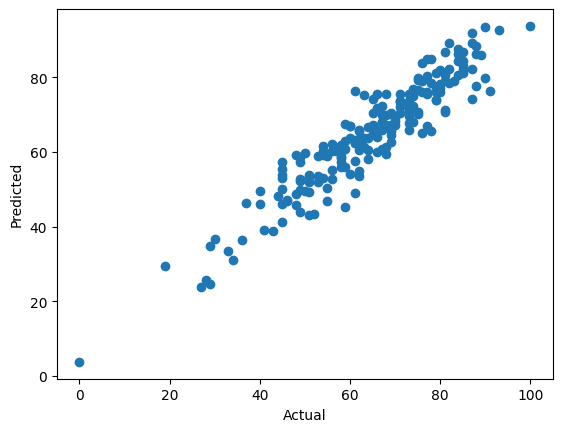

In [38]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');
plt.show()

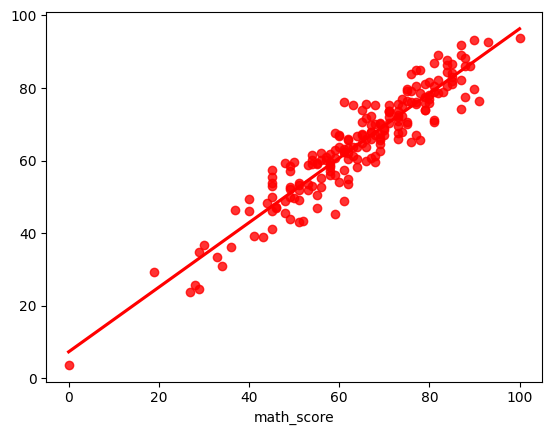

In [39]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');
plt.show()

In [40]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
